# 🧪 Day 1 · Notebook 03 — Student Lab

Time to experiment! Each exercise has:
* a **goal** and an **estimated time**,
* a 💡 **hint**,
* a **TODO** cell for your code (it runs without errors even before you fill it in),
* a **✅ Solution** cell — try first, reveal after!

| # | Exercise | Est. time |
|---|---|---|
| 1 | Optimizers & learning rates | 12 min |
| 2 | BatchNorm + Dropout | 12 min |
| 3 | Early stopping | 15 min |
| 4 | Data augmentation | 12 min |
| 5 | Write a custom `Dataset` | 15 min |
| 6 | Learning-rate schedulers | 10 min |
| ⭐ | Bonus: checkpoint & resume training | 10 min |

To keep experiments fast on a laptop CPU we train on a **10,000-image subset** of FashionMNIST for only a few epochs. Absolute accuracies are therefore lower than in Notebook 02 — focus on **relative** differences between experiments.

> Run the **Setup** section first. If you break something, re-run Setup.

## 0. Setup (run this first)
Same building blocks as Notebook 02, packaged as helpers. Read through `fit()` — the exercises plug into its `scheduler` and `early_stopper` arguments.

In [1]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms

SEED = 42
DATA_DIR = Path("..") / "data"
MODEL_DIR = Path("models"); MODEL_DIR.mkdir(exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
MEAN, STD = 0.2860, 0.3530          # FashionMNIST train statistics (computed in Notebook 02)
N_TRAIN, N_VAL = 10_000, 2_000

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

BASE_TF = transforms.Compose([transforms.ToTensor(), transforms.Normalize((MEAN,), (STD,))])

# Fixed, seeded split indices, so every experiment uses exactly the same images.
_perm = torch.randperm(60_000, generator=torch.Generator().manual_seed(SEED))
TRAIN_IDX, VAL_IDX = _perm[:N_TRAIN].tolist(), _perm[N_TRAIN:N_TRAIN + N_VAL].tolist()


In [2]:
def get_loaders(train_tf=BASE_TF, n_train=N_TRAIN, batch_size=128):
    '''Train/val loaders. train_tf is applied to TRAIN only; validation always uses BASE_TF.'''
    train_ds = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=train_tf)
    val_ds   = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=BASE_TF)
    g = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(Subset(train_ds, TRAIN_IDX[:n_train]), batch_size=batch_size, shuffle=True, generator=g)
    val_loader   = DataLoader(Subset(val_ds, VAL_IDX), batch_size=512, shuffle=False)
    return train_loader, val_loader

class SmallCNN(nn.Module):
    '''The CNN from Notebook 02.'''
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, n_classes))
    def forward(self, x):
        return self.classifier(self.features(x))

def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    tot, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = loss_fn(out, yb)
        loss.backward()
        optimizer.step()
        tot += loss.item() * len(xb); correct += (out.argmax(1) == yb).sum().item(); n += len(xb)
    return tot / n, correct / n

@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    tot, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        tot += loss_fn(out, yb).item() * len(xb); correct += (out.argmax(1) == yb).sum().item(); n += len(xb)
    return tot / n, correct / n

def fit(model, optimizer, train_loader, val_loader, epochs=3, scheduler=None, early_stopper=None, verbose=True):
    '''Generic training loop. Returns a history dict.'''
    model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    for ep in range(1, epochs + 1):
        hist["lr"].append(optimizer.param_groups[0]["lr"])      # LR used during this epoch
        tl, ta = train_one_epoch(model, train_loader, loss_fn, optimizer)
        vl, va = evaluate(model, val_loader, loss_fn)
        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"], [tl, ta, vl, va]):
            hist[k].append(v)
        if verbose:
            print(f"  ep {ep:2d} | lr {hist['lr'][-1]:.5f} | train {tl:.3f}/{ta:.3f} | val {vl:.3f}/{va:.3f}")
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(vl)            # plateau scheduler needs the metric
            else:
                scheduler.step()              # epoch-based schedulers
        if early_stopper is not None and early_stopper.step(vl, model):
            print(f"  ⏹ early stopping after epoch {ep}")
            break
    return hist

def plot_histories(histories, keys=("val_loss", "val_acc"), title=""):
    fig, axes = plt.subplots(1, len(keys), figsize=(5.5 * len(keys), 3.6))
    axes = np.atleast_1d(axes)
    for ax, key in zip(axes, keys):
        for name, h in histories.items():
            ax.plot(range(1, len(h[key]) + 1), h[key], marker="o", label=name)
        ax.set_title(key); ax.set_xlabel("epoch"); ax.grid(alpha=0.3)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    axes[0].legend(fontsize=8)
    fig.suptitle(title); plt.tight_layout(); plt.show()

train_loader, val_loader = get_loaders()
print(f"device={device} | train batches={len(train_loader)} | val images={len(val_loader.dataset)}")

device=cpu | train batches=79 | val images=2000


**Baseline run** — `SmallCNN` + Adam(lr=1e-3), 3 epochs. We will compare against this.

In [3]:
t0 = time.time()
set_seed()
_m = SmallCNN()
baseline_hist = fit(_m, torch.optim.Adam(_m.parameters(), lr=1e-3), train_loader, val_loader, epochs=3)
print(f"baseline done in {time.time() - t0:.1f}s | final val acc {baseline_hist['val_acc'][-1]:.4f}")

  ep  1 | lr 0.00100 | train 0.880/0.678 | val 0.498/0.799
  ep  2 | lr 0.00100 | train 0.518/0.810 | val 0.436/0.842
  ep  3 | lr 0.00100 | train 0.440/0.838 | val 0.397/0.854
baseline done in 10.6s | final val acc 0.8540


---
## Exercise 1 — Optimizers & learning rates (⏱️ 12 min)

**Goal:** train the same `SmallCNN` for 3 epochs with each configuration below and compare validation loss/accuracy:

| name | optimizer |
|---|---|
| `SGD lr=0.01` | `torch.optim.SGD(params, lr=0.01)` |
| `SGD+momentum` | `torch.optim.SGD(params, lr=0.01, momentum=0.9)` |
| `Adam lr=1e-3` | `torch.optim.Adam(params, lr=1e-3)` |
| `Adam lr=0.1` | `torch.optim.Adam(params, lr=0.1)` (deliberately too high) |

💡 **Hint:** store *functions* that build an optimizer from `params` (e.g. `lambda p: torch.optim.SGD(p, lr=0.01)`), because every run needs a **fresh model** and the optimizer must be created for **that model's** parameters. Call `set_seed()` before creating each model so all runs start from identical weights. Use `plot_histories(results)`.

**Questions:** Which converges fastest? What happens with the too-high learning rate — why? Why does momentum help plain SGD?

In [4]:
# TODO: fill the dict with optimizer factories, then train one fresh model per entry.
optimizer_factories = {
    # "SGD lr=0.01": lambda p: torch.optim.SGD(p, lr=0.01),
    # ...
}
results_ex1 = {}
for name, make_opt in optimizer_factories.items():
    # set_seed(); model = ...; results_ex1[name] = fit(...)
    pass
if results_ex1:
    plot_histories(results_ex1, title="Exercise 1")
else:
    print("⏳ Exercise 1 not implemented yet")

⏳ Exercise 1 not implemented yet


#### ✅ Solution (reveal after trying)

SGD lr=0.01
  ep  1 | lr 0.01000 | train 2.111/0.367 | val 1.751/0.589
  ep  2 | lr 0.01000 | train 1.335/0.581 | val 0.997/0.623
  ep  3 | lr 0.01000 | train 0.955/0.661 | val 0.874/0.672
SGD+momentum
  ep  1 | lr 0.01000 | train 1.275/0.553 | val 0.670/0.738
  ep  2 | lr 0.01000 | train 0.669/0.746 | val 0.555/0.768
  ep  3 | lr 0.01000 | train 0.589/0.775 | val 0.515/0.783
Adam lr=1e-3
  ep  1 | lr 0.00100 | train 0.888/0.681 | val 0.528/0.808
  ep  2 | lr 0.00100 | train 0.527/0.806 | val 0.406/0.852
  ep  3 | lr 0.00100 | train 0.443/0.836 | val 0.382/0.857
Adam lr=0.1
  ep  1 | lr 0.10000 | train 28.892/0.094 | val 2.304/0.096
  ep  2 | lr 0.10000 | train 2.306/0.104 | val 2.303/0.105
  ep  3 | lr 0.10000 | train 2.307/0.100 | val 2.303/0.110


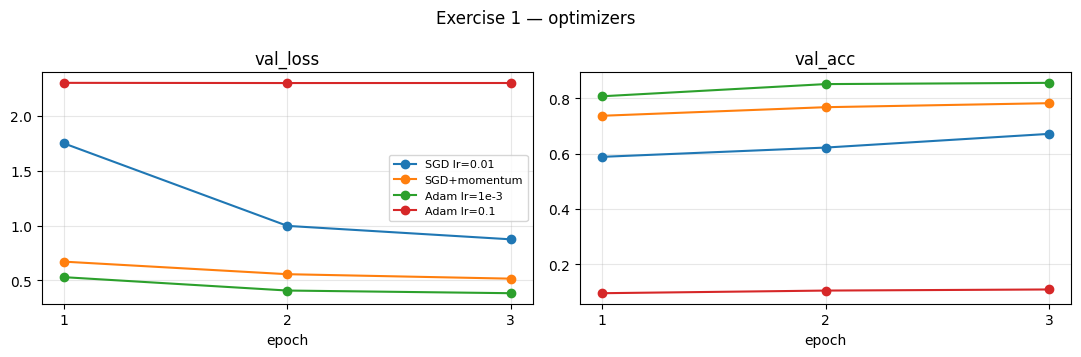

In [5]:
optimizer_factories = {
    "SGD lr=0.01":  lambda p: torch.optim.SGD(p, lr=0.01),
    "SGD+momentum": lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9),
    "Adam lr=1e-3": lambda p: torch.optim.Adam(p, lr=1e-3),
    "Adam lr=0.1":  lambda p: torch.optim.Adam(p, lr=0.1),
}
results_ex1 = {}
for name, make_opt in optimizer_factories.items():
    print(name)
    set_seed()
    model = SmallCNN()
    results_ex1[name] = fit(model, make_opt(model.parameters()), train_loader, val_loader, epochs=3)
plot_histories(results_ex1, title="Exercise 1 — optimizers")
# Typical outcome: Adam 1e-3 and SGD+momentum learn fast; plain SGD 0.01 is slow;
# Adam 0.1 overshoots -> loss stuck around ln(10)=2.30, i.e. ~10% accuracy (random guessing).

---
## Exercise 2 — BatchNorm + Dropout (⏱️ 12 min)

**Goal:** create `ImprovedCNN` by adding
* `nn.BatchNorm2d(C)` **after each convolution** (before the ReLU),
* `nn.Dropout2d(0.1)` after each pooling layer (drops whole feature maps),
* keep `nn.Dropout(0.3)` in the classifier.

Train it with Adam(1e-3) for 3 epochs and compare with `baseline_hist`.

💡 **Hint:** a conv block becomes `Conv2d → BatchNorm2d → ReLU → MaxPool2d → Dropout2d`. BatchNorm normalises activations per channel using batch statistics during training and running averages during evaluation — which is why `model.train()` / `model.eval()` matter so much.

**Questions:** Did the val accuracy improve after 3 epochs? What would happen if you evaluated in `train()` mode?

In [6]:
class ImprovedCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        # TODO: define self.features and self.classifier
        raise NotImplementedError("TODO: build ImprovedCNN")

    def forward(self, x):
        return self.classifier(self.features(x))

try:
    set_seed(); model = ImprovedCNN()
    improved_hist = fit(model, torch.optim.Adam(model.parameters(), lr=1e-3), train_loader, val_loader, epochs=3)
    plot_histories({"baseline": baseline_hist, "BN + dropout": improved_hist})
except NotImplementedError as e:
    print("⏳", e)

⏳ TODO: build ImprovedCNN


#### ✅ Solution (reveal after trying)

  ep  1 | lr 0.00100 | train 0.759/0.729 | val 0.445/0.841
  ep  2 | lr 0.00100 | train 0.473/0.829 | val 0.394/0.853
  ep  3 | lr 0.00100 | train 0.413/0.855 | val 0.376/0.864


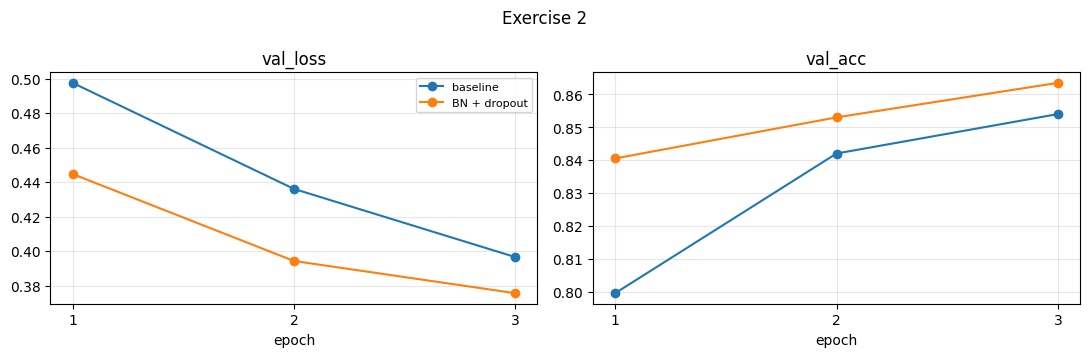

eval()  mode val acc: 0.8635
train() mode val acc: 0.847 <- noisier / usually worse


In [7]:
class ImprovedCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, n_classes))

    def forward(self, x):
        return self.classifier(self.features(x))

set_seed(); model = ImprovedCNN()
improved_hist = fit(model, torch.optim.Adam(model.parameters(), lr=1e-3), train_loader, val_loader, epochs=3)
plot_histories({"baseline": baseline_hist, "BN + dropout": improved_hist}, title="Exercise 2")

# Demonstration: evaluating in the wrong mode changes the result
loss_fn = nn.CrossEntropyLoss()
print("eval()  mode val acc:", round(evaluate(model, val_loader, loss_fn)[1], 4))
model.train()
with torch.no_grad():   # evaluate "by hand" in train mode (BN uses batch stats, dropout active)
    correct = sum((model(x.to(device)).argmax(1) == y.to(device)).sum().item() for x, y in val_loader)
print("train() mode val acc:", round(correct / len(val_loader.dataset), 4), "<- noisier / usually worse")
# Note: forwarding in train() mode also updated BN running stats; in real code never evaluate in train mode.

---
## Exercise 3 — Early stopping (⏱️ 15 min)

When a model starts to **overfit**, validation loss rises while training loss keeps falling. *Early stopping* monitors validation loss and stops when it hasn't improved for `patience` epochs, then **restores the best weights**.

**Goal:** implement the `EarlyStopping` class:
* `step(val_loss, model)` returns `True` when training should stop,
* an "improvement" means `val_loss < best - min_delta`,
* on improvement, store a `copy.deepcopy(model.state_dict())` and reset the counter,
* `restore(model)` loads the best weights back.

To *provoke* overfitting quickly, we train on only **2,000** images with a slightly higher learning rate (Adam, `lr=3e-3`) for up to **25** epochs. Watch the training loss keep falling while the validation loss turns back up.

💡 **Hint:** keep `self.best = float("inf")`, `self.counter = 0`, `self.best_state = None`, `self.best_epoch`.

In [8]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience, self.min_delta = patience, min_delta
        # TODO: initialise best, counter, best_state, best_epoch, epoch

    def step(self, val_loss, model) -> bool:
        raise NotImplementedError("TODO: implement EarlyStopping.step")

    def restore(self, model):
        raise NotImplementedError("TODO: implement EarlyStopping.restore")

small_train_loader, _ = get_loaders(n_train=2_000)
try:
    set_seed(); model = SmallCNN()
    stopper = EarlyStopping(patience=3)
    es_hist = fit(model, torch.optim.Adam(model.parameters(), lr=3e-3), small_train_loader, val_loader,
                  epochs=25, early_stopper=stopper)
    stopper.restore(model)
except NotImplementedError as e:
    print("⏳", e)

  ep  1 | lr 0.00300 | train 1.537/0.458 | val 0.752/0.719
⏳ TODO: implement EarlyStopping.step


#### ✅ Solution (reveal after trying)

  ep  1 | lr 0.00300 | train 1.537/0.458 | val 0.752/0.719
  ep  2 | lr 0.00300 | train 0.784/0.707 | val 0.643/0.757
  ep  3 | lr 0.00300 | train 0.628/0.754 | val 0.509/0.814
  ep  4 | lr 0.00300 | train 0.565/0.786 | val 0.494/0.821
  ep  5 | lr 0.00300 | train 0.495/0.824 | val 0.466/0.833
  ep  6 | lr 0.00300 | train 0.446/0.829 | val 0.478/0.827
  ep  7 | lr 0.00300 | train 0.443/0.824 | val 0.428/0.850
  ep  8 | lr 0.00300 | train 0.367/0.860 | val 0.411/0.851
  ep  9 | lr 0.00300 | train 0.353/0.862 | val 0.449/0.845
  ep 10 | lr 0.00300 | train 0.327/0.875 | val 0.419/0.854
  ep 11 | lr 0.00300 | train 0.285/0.892 | val 0.420/0.856
  ⏹ early stopping after epoch 11
best epoch = 8, best val loss = 0.4109
val loss/acc after restore: [0.4109, 0.851]


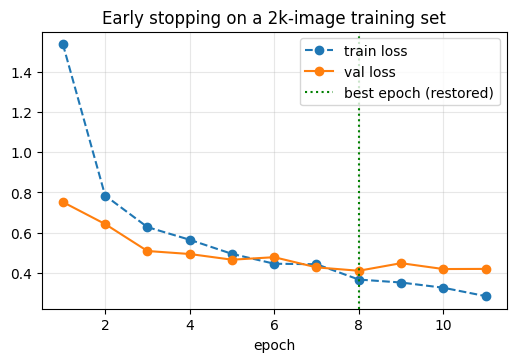

In [9]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience, self.min_delta = patience, min_delta
        self.best = float("inf")
        self.counter = 0
        self.best_state = None
        self.best_epoch = 0
        self.epoch = 0

    def step(self, val_loss, model) -> bool:
        self.epoch += 1
        if val_loss < self.best - self.min_delta:
            self.best, self.counter, self.best_epoch = val_loss, 0, self.epoch
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

small_train_loader, _ = get_loaders(n_train=2_000)
set_seed(); model = SmallCNN()
stopper = EarlyStopping(patience=3)
es_hist = fit(model, torch.optim.Adam(model.parameters(), lr=3e-3), small_train_loader, val_loader,
              epochs=25, early_stopper=stopper)
stopper.restore(model)
print(f"best epoch = {stopper.best_epoch}, best val loss = {stopper.best:.4f}")
print("val loss/acc after restore:", [round(v, 4) for v in evaluate(model, val_loader, nn.CrossEntropyLoss())])

plt.figure(figsize=(6, 3.6))
ep = range(1, len(es_hist["train_loss"]) + 1)
plt.plot(ep, es_hist["train_loss"], "o--", label="train loss")
plt.plot(ep, es_hist["val_loss"], "o-", label="val loss")
plt.axvline(stopper.best_epoch, color="green", ls=":", label="best epoch (restored)")
plt.xlabel("epoch"); plt.legend(); plt.title("Early stopping on a 2k-image training set"); plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.show()

---
## Exercise 4 — Data augmentation (⏱️ 12 min)

Augmentation creates *new, plausible* training images on the fly, so the model sees a slightly different version of every image in every epoch. It's a strong regulariser.

**Goal:**
1. Build `aug_tf` = `RandomHorizontalFlip()` + `RandomAffine(degrees=10, translate=(0.1, 0.1))` + `ToTensor()` + `Normalize`.
2. Visualise 8 augmented versions of the same training image.
3. Train `SmallCNN` for 3 epochs with `get_loaders(train_tf=aug_tf)` and compare with the baseline.

💡 **Hint:** geometric transforms operate on the PIL image, so put them **before** `ToTensor()`. Augment the **training set only** — `get_loaders` already keeps validation on `BASE_TF`.

**Questions:** Why would `RandomVerticalFlip` be a bad idea here? Why might augmentation *lower* accuracy after only 3 epochs, yet help with longer training?

In [10]:
aug_tf = None   # TODO: transforms.Compose([...])

if aug_tf is None:
    print("⏳ Exercise 4 not implemented yet")
else:
    pass  # TODO: visualise + train

⏳ Exercise 4 not implemented yet


#### ✅ Solution (reveal after trying)

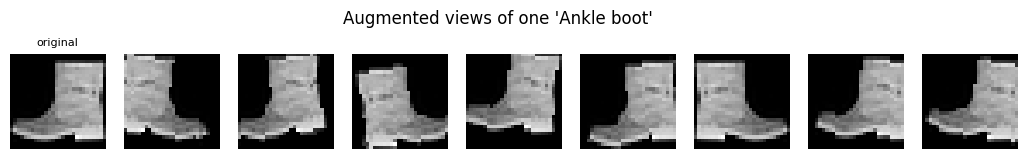

  ep  1 | lr 0.00100 | train 1.181/0.556 | val 0.686/0.719
  ep  2 | lr 0.00100 | train 0.794/0.701 | val 0.579/0.767
  ep  3 | lr 0.00100 | train 0.705/0.735 | val 0.554/0.780


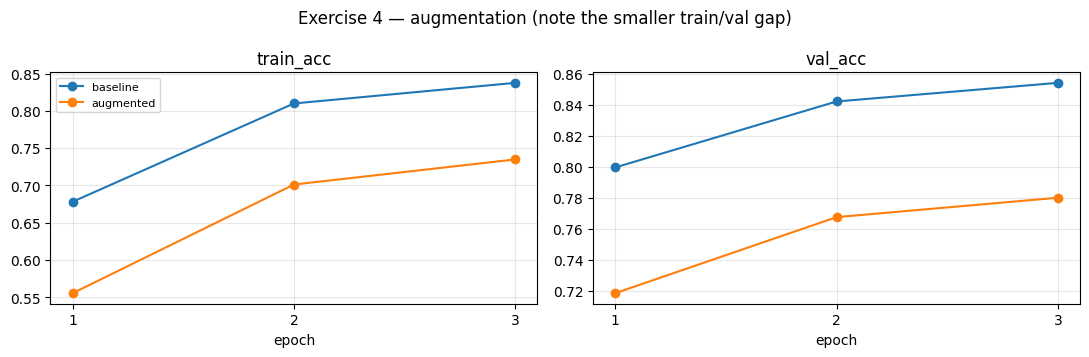

In [11]:
aug_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])

raw = datasets.FashionMNIST(DATA_DIR, train=True, download=True)   # PIL images, no transform
pil_img, lbl = raw[TRAIN_IDX[0]]
fig, axes = plt.subplots(1, 9, figsize=(13, 1.9))
axes[0].imshow(pil_img, cmap="gray"); axes[0].set_title("original", fontsize=8)
for ax in axes[1:]:
    ax.imshow((aug_tf(pil_img).squeeze(0) * STD + MEAN).numpy(), cmap="gray")
for ax in axes: ax.axis("off")
plt.suptitle(f"Augmented views of one '{raw.classes[lbl]}'"); plt.show()

aug_train_loader, _ = get_loaders(train_tf=aug_tf)
set_seed(); model = SmallCNN()
aug_hist = fit(model, torch.optim.Adam(model.parameters(), lr=1e-3), aug_train_loader, val_loader, epochs=3)
plot_histories({"baseline": baseline_hist, "augmented": aug_hist}, keys=("train_acc", "val_acc"),
               title="Exercise 4 — augmentation (note the smaller train/val gap)")
# Expect LOWER accuracy than the baseline after only 3 epochs: the task got harder (every image is
# randomly shifted/rotated), so the model needs more epochs to converge. Notice the train accuracy
# drops even more than val accuracy -> much less overfitting. With 15-20 epochs on the full data,
# augmentation typically ends up ahead of the baseline.

---
## Exercise 5 — Write a custom `Dataset` (⏱️ 15 min)

Real projects rarely use a ready-made `torchvision` dataset. A map-style `Dataset` needs just **three methods**:

```python
class MyDataset(Dataset):
    def __init__(self, ...):   # load / generate / index your data
    def __len__(self):         # number of samples
    def __getitem__(self, i):  # return ONE sample: (features, label)
```

**Goal:** implement `MoonsDataset` wrapping scikit-learn's `make_moons` (2-D points, 2 classes):
* `__init__(self, n_samples, noise=0.2, seed=0)` — generate `X, y` with `make_moons(n_samples, noise=noise, random_state=seed)`,
* `__getitem__` returns `(x, y)` with `x` a `float32` tensor of shape `(2,)` and `y` an `int64` scalar tensor.

Then train a small MLP (`2 → 16 → 16 → 2`) for 50 epochs with Adam(lr=0.01) on a 1,000-sample train set and evaluate on a 500-sample test set (different seed). Plot the decision boundary.

💡 **Hint:** convert once in `__init__` (`torch.tensor(X, dtype=torch.float32)`), not in every `__getitem__` call. You can reuse `train_one_epoch`/`evaluate` from Setup.

In [12]:
from sklearn.datasets import make_moons

class MoonsDataset(Dataset):
    def __init__(self, n_samples, noise=0.2, seed=0):
        raise NotImplementedError("TODO: implement MoonsDataset")

    def __len__(self):
        raise NotImplementedError

    def __getitem__(self, idx):
        raise NotImplementedError

try:
    ds = MoonsDataset(1_000)
    print(len(ds), ds[0])
except NotImplementedError as e:
    print("⏳", e)

⏳ TODO: implement MoonsDataset


#### ✅ Solution (reveal after trying)

len: 1000 | sample: tensor([2.0861, 0.5740]) torch.float32 tensor(1) torch.int64
test loss/acc: [0.0997, 0.962]


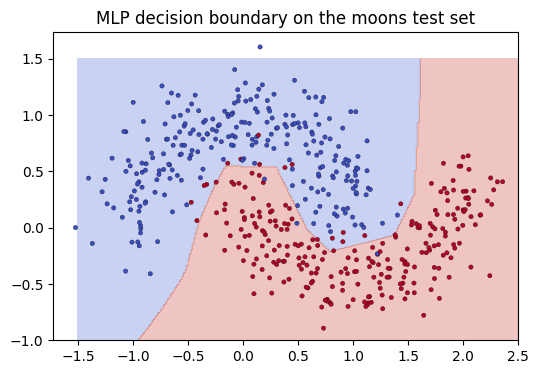

In [13]:
from sklearn.datasets import make_moons

class MoonsDataset(Dataset):
    def __init__(self, n_samples, noise=0.2, seed=0):
        X, y = make_moons(n_samples=n_samples, noise=noise, random_state=seed)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

moons_train, moons_test = MoonsDataset(1_000, seed=0), MoonsDataset(500, seed=1)
x0, y0 = moons_train[0]
print("len:", len(moons_train), "| sample:", x0, x0.dtype, y0, y0.dtype)

set_seed()
m_train_loader = DataLoader(moons_train, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(SEED))
m_test_loader  = DataLoader(moons_test, batch_size=256)
mlp = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 16), nn.ReLU(), nn.Linear(16, 2)).to(device)
opt = torch.optim.Adam(mlp.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()
for epoch in range(50):
    train_one_epoch(mlp, m_train_loader, loss_fn, opt)
print("test loss/acc:", [round(v, 4) for v in evaluate(mlp, m_test_loader, loss_fn)])

# Decision boundary: classify every point of a dense grid
xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 300), np.linspace(-1.0, 1.5, 300))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32, device=device)
mlp.eval()
with torch.no_grad():
    zz = mlp(grid).argmax(1).cpu().numpy().reshape(xx.shape)
plt.figure(figsize=(6, 4))
plt.contourf(xx, yy, zz, alpha=0.3, cmap="coolwarm")
plt.scatter(moons_test.X[:, 0], moons_test.X[:, 1], c=moons_test.y, s=10, cmap="coolwarm", edgecolor="k", linewidth=0.2)
plt.title("MLP decision boundary on the moons test set"); plt.show()

---
## Exercise 6 — Learning-rate schedulers (⏱️ 10 min)

A high learning rate early on makes fast progress; a lower one later lets the model settle into a minimum. **Schedulers** change the LR during training.

**Goal:** train `SmallCNN` with Adam(lr=3e-3) for 4 epochs using each scheduler, and plot the LR (`hist["lr"]`) and val accuracy per epoch:
* `StepLR(optimizer, step_size=2, gamma=0.3)` — multiply LR by 0.3 every 2 epochs,
* `CosineAnnealingLR(optimizer, T_max=4)` — smooth cosine decay to ~0,
* no scheduler (constant LR) as a reference.

💡 **Hint:** the scheduler is created **from the optimizer**: `sched = torch.optim.lr_scheduler.StepLR(opt, step_size=2, gamma=0.3)`; pass it as `fit(..., scheduler=sched)`. `fit` calls `scheduler.step()` once per epoch, *after* `optimizer.step()` — that order matters.

In [14]:
scheduler_factories = {
    # "constant": lambda opt: None,
    # "StepLR":   lambda opt: torch.optim.lr_scheduler.StepLR(opt, step_size=2, gamma=0.3),
    # "Cosine":   ...
}
results_ex6 = {}
for name, make_sched in scheduler_factories.items():
    pass  # TODO: set_seed(); model; optimizer; scheduler; fit(...)
if results_ex6:
    plot_histories(results_ex6, keys=("lr", "val_acc"))
else:
    print("⏳ Exercise 6 not implemented yet")

⏳ Exercise 6 not implemented yet


#### ✅ Solution (reveal after trying)

constant
  ep  1 | lr 0.00300 | train 0.749/0.724 | val 0.448/0.836
  ep  2 | lr 0.00300 | train 0.444/0.834 | val 0.379/0.857
  ep  3 | lr 0.00300 | train 0.365/0.864 | val 0.347/0.862
  ep  4 | lr 0.00300 | train 0.320/0.880 | val 0.353/0.873
StepLR
  ep  1 | lr 0.00300 | train 0.820/0.698 | val 0.480/0.816
  ep  2 | lr 0.00300 | train 0.476/0.822 | val 0.460/0.814
  ep  3 | lr 0.00090 | train 0.370/0.864 | val 0.343/0.871
  ep  4 | lr 0.00090 | train 0.335/0.878 | val 0.323/0.876
Cosine
  ep  1 | lr 0.00300 | train 0.756/0.718 | val 0.436/0.833
  ep  2 | lr 0.00256 | train 0.449/0.836 | val 0.414/0.841
  ep  3 | lr 0.00150 | train 0.362/0.867 | val 0.327/0.877
  ep  4 | lr 0.00044 | train 0.311/0.885 | val 0.321/0.876


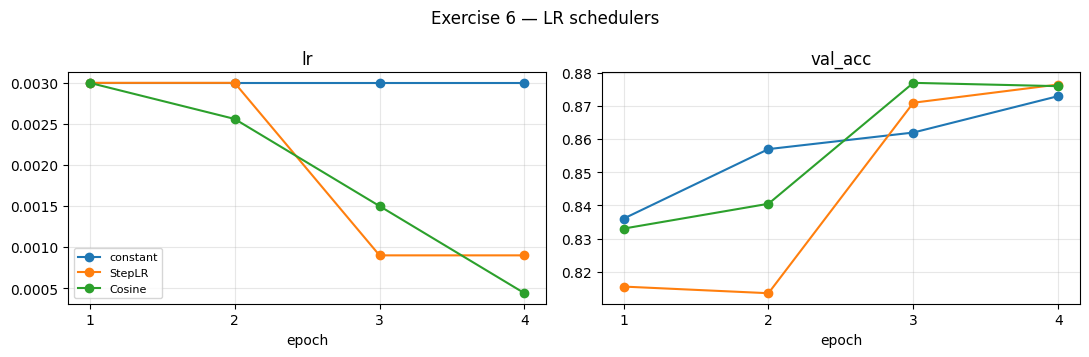

In [15]:
scheduler_factories = {
    "constant": lambda opt: None,
    "StepLR":   lambda opt: torch.optim.lr_scheduler.StepLR(opt, step_size=2, gamma=0.3),
    "Cosine":   lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=4),
}
results_ex6 = {}
for name, make_sched in scheduler_factories.items():
    print(name)
    set_seed()
    model = SmallCNN()
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    results_ex6[name] = fit(model, opt, train_loader, val_loader, epochs=4, scheduler=make_sched(opt))
plot_histories(results_ex6, keys=("lr", "val_acc"), title="Exercise 6 — LR schedulers")

---
## ⭐ Bonus — Checkpoint & resume training (⏱️ 10 min)

Long training jobs crash, get pre-empted, or hit time limits. A **checkpoint** stores everything needed to continue *exactly* where you left off:

```python
{"epoch": ..., "model_state": model.state_dict(), "optimizer_state": optimizer.state_dict()}
```
The **optimizer state** matters: Adam keeps running averages per parameter — without it, resuming is not equivalent to continuing.

**Goal:**
1. Train a `SmallCNN` for 1 epoch, save a checkpoint dict to `models/lab_checkpoint.pt`.
2. Create a **fresh** model and optimizer, load the checkpoint into both, and train 1 more epoch.
3. Print the epoch counter and val accuracy before and after resuming.

💡 **Hint:** `torch.save(dict, path)`; `ckpt = torch.load(path, map_location=device, weights_only=True)`; `model.load_state_dict(ckpt["model_state"])`; `optimizer.load_state_dict(ckpt["optimizer_state"])`. A dict containing only tensors, ints and standard containers loads fine with the default `weights_only=True`.

In [ ]:
# TODO: your code here

#### ✅ Solution (reveal after trying)

In [16]:
CKPT = MODEL_DIR / "lab_checkpoint.pt"
loss_fn = nn.CrossEntropyLoss()

set_seed()
model = SmallCNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
train_one_epoch(model, train_loader, loss_fn, opt)
print("after epoch 1 -> val acc", round(evaluate(model, val_loader, loss_fn)[1], 4))
torch.save({"epoch": 1, "model_state": model.state_dict(), "optimizer_state": opt.state_dict()}, CKPT)
print("checkpoint saved:", CKPT)

# ---- imagine the kernel crashed here; start from scratch ----
model2 = SmallCNN().to(device)
opt2 = torch.optim.Adam(model2.parameters(), lr=1e-3)
ckpt = torch.load(CKPT, map_location=device, weights_only=True)
model2.load_state_dict(ckpt["model_state"])
opt2.load_state_dict(ckpt["optimizer_state"])
start_epoch = ckpt["epoch"] + 1
print(f"resumed at epoch {start_epoch} -> val acc", round(evaluate(model2, val_loader, loss_fn)[1], 4))
train_one_epoch(model2, train_loader, loss_fn, opt2)
print(f"after epoch {start_epoch} -> val acc", round(evaluate(model2, val_loader, loss_fn)[1], 4))

after epoch 1 -> val acc 0.7895
checkpoint saved: models\lab_checkpoint.pt
resumed at epoch 2 -> val acc 0.7895
after epoch 2 -> val acc 0.824


---
## 🏁 Wrap-up

Discuss with your neighbour:
1. Which single change gave the biggest improvement? Would that still be true with 20 epochs on the full data?
2. Which techniques are about **optimisation** (training faster/better) and which about **generalisation** (less overfitting)?
3. What would you try next to push FashionMNIST above 93%?

**Tomorrow (Day 2):** instead of training from scratch, we'll start from a network **pretrained on ImageNet** (MobileNetV2), fine-tune it on CIFAR-10 (*transfer learning*), and then make it smaller and faster with **quantization**.